# Overview

## Description

This is a template notebook to tune up a single qubit using the LabOneQ workflow architecture. The following tune-up experiments are implemented:

1. Resonator Spectroscopy
2. Qubit Spectroscopy
3. Amplitude Rabi Experiment
4. Ramsey Experiment
5. T1 Lifetime experiment
6. DRAG Calibration
7. Hahn-Echo Experiment

All experiments can be performed on the ge and ef transition.

## Changelog

All changes must be logged here! Do not make changes to this notebook other than expanding or modifying the standard experiments in a meaningful! All device-specific parameters and measurements have to be done in a different notebook!

Stick to semantic versioning:
- **Last Digit**: Fix a bug that does not add any new features and is backwards compatible -> increment last digit by one (e.g. 0.0.4 to 0.0.5)

- **Middle Digit**: Add a new feature while keeping backwards compatibility (older versions can still be executed without any modifications) -> increment middle digit by one and set last digit to 0 (e.g. 1.2.12 to 1.3.0)

- **First Digit**: Make changes that will break older versions, making them incompatible with the new version -> increment first digit by one and set all other digits to 0 (e.g. 3.2.9 to 4.0.0)

**Current Version:** 1.0.0

**2026-07-23**, *Elias*: Created this template notebook and added resonator and qubit spectroscopy, amplitude Rabi, Ramsey T1 and DRAG

# Package Imports and Initialization

## LabOne Q Libraries

In [1]:
# LabOne Q:
from laboneq.simple import *
from laboneq.dsl.quantum import QPU
from laboneq.contrib.example_helpers.generate_descriptor import generate_descriptor
from laboneq.workflow.logbook import LoggingStore
from laboneq.serializers import load, save

# LabOne Q Applications:
from laboneq_applications.qpu_types.tunable_transmon import (
    TunableTransmonQubit,
    TunableTransmonOperations,
)

# Plot:
from laboneq.contrib.example_helpers.plotting.plot_helpers import plot_results, plot_simulation

# Workflows:
from laboneq_applications.experiments import (
    resonator_spectroscopy,
    resonator_spectroscopy_amplitude,
    qubit_spectroscopy,
    amplitude_rabi,
    ramsey,
    drag_q_scaling,
    lifetime_measurement,
    echo,
)

## Other Imports

In [2]:
from copy import deepcopy
from pprint import pprint
import numpy as np
import time
from pathlib import Path
import os

In [3]:
def set_transition(transition: str):
    assert transition in ['ge', 'ef'], "Choose transition from 'ge' or 'ef'!"
    return transition

def log_sweep_help(t1_min: float, t1_max: float, t1_num: int):
    t1_log_sweep = np.logspace(np.log10(t1_max / t1_num / 10), np.log10(t1_max), t1_num - 1)
    t1_log_sweep_arr = np.append([0.0], t1_log_sweep)
    return t1_log_sweep_arr

## Descriptor and Device Setup

In [4]:
number_of_qubits = 1

descriptor = generate_descriptor(
    #pqsc=["DEV10001"],
    shfqc_2=["DEV12192"],
    number_data_qubits=number_of_qubits,
    multiplex=True,
    number_multiplex=number_of_qubits,
    include_cr_lines=False,
    ip_address="localhost",
    #options = "SHFQC/QC2CH",
)

setup = DeviceSetup.from_descriptor(descriptor, "localhost")
setup.instruments[0].device_options = "SHFQC/QC2CH"

In [5]:
qubits = TunableTransmonQubit.from_device_setup(setup)

## Qubit Initialization

In [6]:
cooldown_start_date = '2026-07-03' # YYYY-MM-DD
sample_name = 'ES-008-BC_2-1_8853'
qubit_name = 'Q1'

assert cooldown_start_date != '', 'Enter cooldown name'
assert sample_name != '', 'Enter sample name'
assert qubit_name != '', 'Enter qubit name'

In [13]:
for q in qubits:
    q.parameters.ge_drive_pulse["sigma"] = 0.25
    q.parameters.readout_amplitude = 0.5
    q.parameters.reset_delay_length = 150e-6
    q.parameters.readout_range_out = -25
    q.parameters.readout_lo_frequency = 5e9
    q.parameters.drive_range = 5
    q.parameters.readout_range_in = -45
    q.parameters.readout_integration_delay = 80e-9

qubits[0].parameters.drive_lo_frequency = 3.6e9
qubits[0].parameters.resonance_frequency_ge = 3.745e9
qubits[0].parameters.resonance_frequency_ef = 3.500e9
qubits[0].parameters.readout_resonator_frequency = 5.0374e9
qubits[0].parameters.spectroscopy_length = 5e-6
qubits[0].parameters.spectroscopy_amplitude = 0.5
qubits[0].uid = qubit_name

In [14]:
qops = TunableTransmonOperations()
qpu = QPU(qubits, quantum_operations=qops)

In [15]:
for q in qubits:
    print("-------------")
    print("Qubit UID:", q.uid)
    print("Qubit logical signals:")
    for sig, lsg in q.signals.items():
        print(f"  {sig:<10} ('{lsg:>10}')")

-------------
Qubit UID: Q1
Qubit logical signals:
  drive      ('  q0/drive')
  drive_ef   ('q0/drive_ef')
  measure    ('q0/measure')
  acquire    ('q0/acquire')


## LabOne Q Session Connection

In [16]:
session = Session(setup)
session.connect(do_emulation=False)

[2026.07.23 13:31:22.578] INFO    Logging initialized from [Default inline config in laboneq.laboneq_logging] logdir is C:\Users\phys-pico-lab\Documents\laboneq_workflow_notebooks\samples\ES-008-BC_2-1_8853\laboneq_output\log
[2026.07.23 13:31:22.582] INFO    Disconnecting from all devices and servers...
[2026.07.23 13:31:22.582] INFO    Successfully disconnected from all devices and servers.
[2026.07.23 13:31:22.597] INFO    VERSION: laboneq 26.4.0
[2026.07.23 13:31:22.602] INFO    Connecting to data server at localhost:8004
[2026.07.23 13:31:22.617] INFO    Connected to Zurich Instruments LabOne Data Server version 26.04.1.6 at localhost:8004
[2026.07.23 13:31:22.634] INFO    Configuring the device setup
[2026.07.23 13:31:22.653] INFO    The device setup is configured
[2026.07.23 13:31:22.912] INFO    System profile saved to C:\Users\phys-pico-lab\AppData\Local\laboneq\profiles\unknown-613335402d7b7f78058d100a7c9ddd62592a6fd7431fa79c3e5a4ab0cfd13ec3.yaml


## Data Saving

In [17]:
data_root_directory = os.path.join('N:\\', 'xld', 'qubit_thermometry_v2', sample_name, f'COOLDOWN_{cooldown_start_date}', qubit_name)
qpu_file_path = os.path.join('N:\\', 'xld', 'qubit_thermometry_v2', sample_name, f'COOLDOWN_{cooldown_start_date}', f'{sample_name}_qpu.json')

if not os.path.isdir(data_root_directory):
    os.makedirs(data_root_directory, exist_ok=True)

print(f'Saving data to: {data_root_directory}')

Saving data to: N:\xld\qubit_thermometry_v2\ES-008-BC_2-1_8853\COOLDOWN_2026-07-03\Q1


In [18]:
folder_store = workflow.logbook.FolderStore(data_root_directory)
folder_store.activate()

logging_store = LoggingStore()
logging_store.activate()

# Tune-Up Experiments

## Spectroscopy

### Resonator Spectroscopy

#### Experiment Parameters

In [30]:
update_global_parameters = True

readout_range_out = -25
readout_range_in = -45
readout_amplitude = 0.2
n_avg_exponent = 15

freq_range = 10e6
n_points = 101

temporary_parameters = {}
temp_pars = deepcopy(qubits[0].parameters)
temp_pars.readout_range_out = readout_range_out
temp_pars.readout_range_in = readout_range_in
temp_pars.readout_amplitude = readout_amplitude
temporary_parameters[q.uid] = temp_pars

#### Run Workflow

[2026.07.23 13:33:59.335] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.07.23 13:33:59.341] INFO      Workflow 'resonator_spectroscopy': execution started at 2026-07-23            
[2026.07.23 13:33:59.341] INFO      10:33:59.335868Z                                                              
[2026.07.23 13:33:59.341] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.07.23 13:33:59.684] INFO    Task 'temporary_qpu': started at 2026-07-23 10:33:59.678472Z
[2026.07.23 13:33:59.806] INFO    Task 'temporary_qpu': ended at 2026-07-23 10:33:59.806275Z
[2026.07.23 13:34:00.005] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-07-23 
[2026.07.23 13:34:00.005] INFO    10:34:00.005765Z
[2026.07.23 13:34:00.058] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-07-23 10:34:00.058341Z
[2026.07.23 13:34:00.136] INFO    Task 'create_experiment': started at 2026-07-23 10:

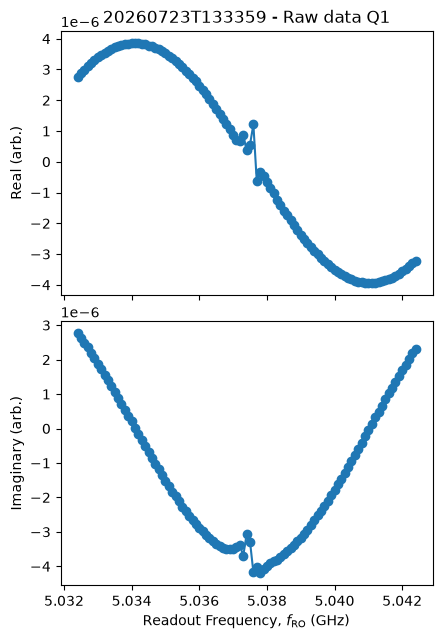

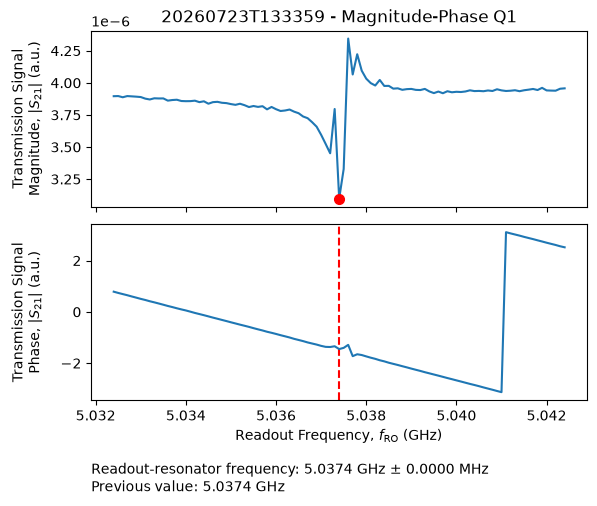

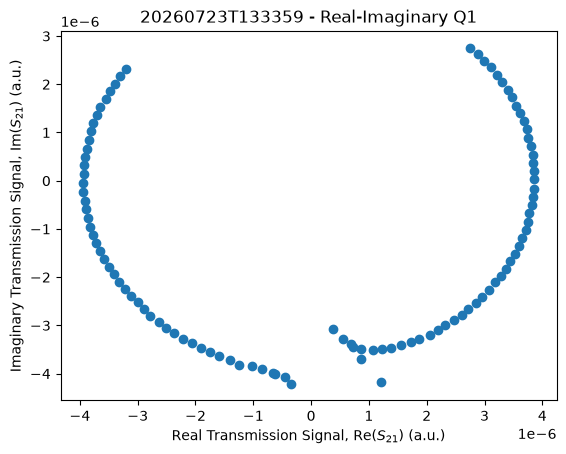

In [31]:
options = resonator_spectroscopy.experiment_workflow.options()
options.count(2**n_avg_exponent)
options.close_figures(False)

qubit_to_measure = qubits[0]

frequencies = qubits[0].parameters.readout_resonator_frequency + np.linspace(
    -freq_range / 2, freq_range / 2, n_points
)

exp_workflow = resonator_spectroscopy.experiment_workflow(
    session=session,
    qpu=qpu,
    qubit=qubit_to_measure.uid,
    frequencies=frequencies,
    options=options,
    temporary_parameters=temporary_parameters
)
workflow_result = exp_workflow.run()

#### Update Parameters

In [32]:
if update_global_parameters:
    qubit_to_measure.parameters = deepcopy(temporary_parameters[qubit_to_measure.uid])
    save(qpu, qpu_file_path)
    print('Updated global experiment parameters!\n')

analysis_workflow_result= workflow_result.tasks["analysis_workflow"]
qubit_parameters = analysis_workflow_result.output
pprint(qubit_parameters)
resonator_spectroscopy.update_qpu(qpu, qubit_parameters["new_parameter_values"])
print("\nReadout resonator frequency: ", qubit_to_measure.parameters.readout_resonator_frequency * 1e-9, ' GHz')

Updated global experiment parameters!

{'new_parameter_values': {'Q1': {'readout_resonator_frequency': 5037400000.0+/-0}},
 'old_parameter_values': {'Q1': {'readout_resonator_frequency': 5037400000.0}}}

Readout resonator frequency:  5.0374  GHz


## Qubit Spectroscopy

#### Experiment Parameters

In [35]:
update_global_parameters = True

spectroscopy_length = 2e-6
spectroscopy_amplitude = 1
readout_amplitude = 0.1
drive_range = -30
n_avg_exponent = 13

freq_range = 100e6
n_points = 251

temporary_parameters = {}
temp_pars = deepcopy(qubits[0].parameters)
temp_pars.spectroscopy_length = spectroscopy_length
temp_pars.spectroscopy_amplitude = spectroscopy_amplitude
temp_pars.readout_amplitude = readout_amplitude
temp_pars.drive_range = drive_range
temporary_parameters[q.uid] = temp_pars

#### Run Workflow

[2026.07.23 13:36:14.943] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.07.23 13:36:14.943] INFO      Workflow 'qubit_spectroscopy': execution started at 2026-07-23                
[2026.07.23 13:36:14.943] INFO      10:36:14.943169Z                                                              
[2026.07.23 13:36:14.953] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.07.23 13:36:15.323] INFO    Task 'temporary_qpu': started at 2026-07-23 10:36:15.323984Z
[2026.07.23 13:36:15.359] INFO    Task 'temporary_qpu': ended at 2026-07-23 10:36:15.359930Z
[2026.07.23 13:36:15.524] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-07-23 
[2026.07.23 13:36:15.526] INFO    10:36:15.524798Z
[2026.07.23 13:36:15.636] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-07-23 10:36:15.636306Z
[2026.07.23 13:36:15.905] INFO    Task 'create_experiment': started at 2026-07-23 10:

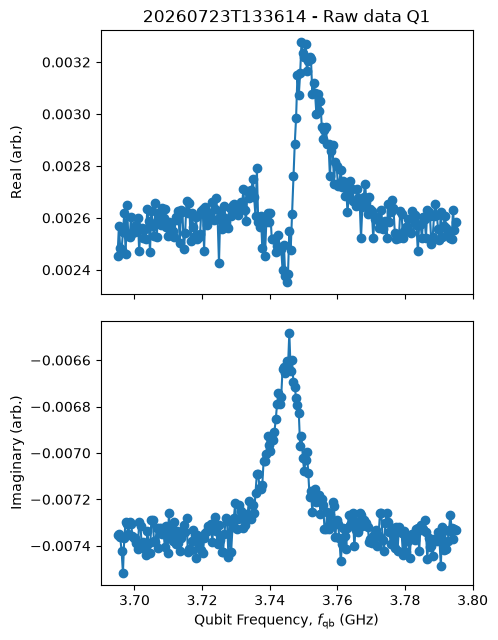

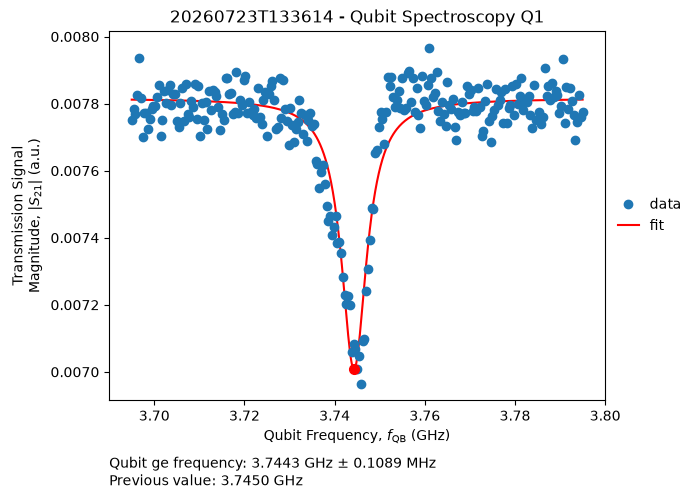

In [36]:
options = qubit_spectroscopy.experiment_workflow.options()
options.count(2**n_avg_exponent)
options.update(False) 
options.close_figures(False)

qubits_to_measure = [qubits[0]]

frequencies = [
    temporary_parameters[q.uid].resonance_frequency_ge + np.linspace(- freq_range / 2, freq_range / 2, n_points)
    for q in qubits_to_measure
]
exp_workflow = qubit_spectroscopy.experiment_workflow(
    session=session,
    qpu=qpu,
    qubits=[q.uid for q in qubits_to_measure],
    frequencies=frequencies,
    options=options,
    temporary_parameters=temporary_parameters
)
workflow_result = exp_workflow.run()

#### Update Parameters

In [37]:
manual_center_frequency = 5.15e9
temporary_parameters[qubit_to_measure.uid].resonance_frequency_ge = manual_center_frequency

In [38]:
if update_global_parameters:
    qubit_to_measure.parameters = deepcopy(temporary_parameters[qubit_to_measure.uid])
    save(qpu, qpu_file_path)
    print('Updated global experiment parameters!\n')

analysis_workflow_result= workflow_result.tasks["analysis_workflow"]
qubit_parameters = analysis_workflow_result.output
pprint(qubit_parameters)
qubit_spectroscopy.update_qpu(qpu, qubit_parameters["new_parameter_values"])
print("Readout resonance frequency ge: ", qubit_to_measure.parameters.resonance_frequency_ge)

Updated global experiment parameters!

{'new_parameter_values': {'Q1': {'resonance_frequency_ge': 3744291137.7284007+/-108941.20187909898}},
 'old_parameter_values': {'Q1': {'resonance_frequency_ge': 3745000000.0}}}
Readout resonance frequency ge:  3744291137.7284007


# Control Pulses

## Amplitude Rabi

#### Experiment Parameters

In [40]:
update_global_parameters = True

transition = set_transition('ge')

drive_range = -5
drive_length = 50e-9
readout_amplitude = 0.5
n_avg_exponent = 13

amp_min = 0
amp_max = 1
n_amp = 21

temporary_parameters = {}
temp_pars = deepcopy(qubits[0].parameters)
temp_pars.drive_range = drive_range
temp_pars.readout_amplitude = readout_amplitude
if transition == 'ge':
    temp_pars.ge_drive_length = drive_length
elif transition == 'ef':
    temp_pars.ef_drive_length = drive_length
temporary_parameters[q.uid] = temp_pars

#### Run Workflow

[2026.07.23 13:37:08.330] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.07.23 13:37:08.330] INFO      Workflow 'amplitude_rabi': execution started at 2026-07-23 10:37:08.330609Z   
[2026.07.23 13:37:08.330] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.07.23 13:37:09.053] INFO    Task 'temporary_qpu': started at 2026-07-23 10:37:09.053481Z
[2026.07.23 13:37:09.122] INFO    Task 'temporary_qpu': ended at 2026-07-23 10:37:09.122314Z
[2026.07.23 13:37:09.324] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-07-23 
[2026.07.23 13:37:09.324] INFO    10:37:09.324271Z
[2026.07.23 13:37:09.389] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-07-23 10:37:09.389093Z
[2026.07.23 13:37:09.499] INFO    Task 'create_experiment': started at 2026-07-23 10:37:09.499311Z
[2026.07.23 13:37:09.758] INFO    Task 'create_experiment': ended at 2026-07-23 10:37:09.758377Z
[202

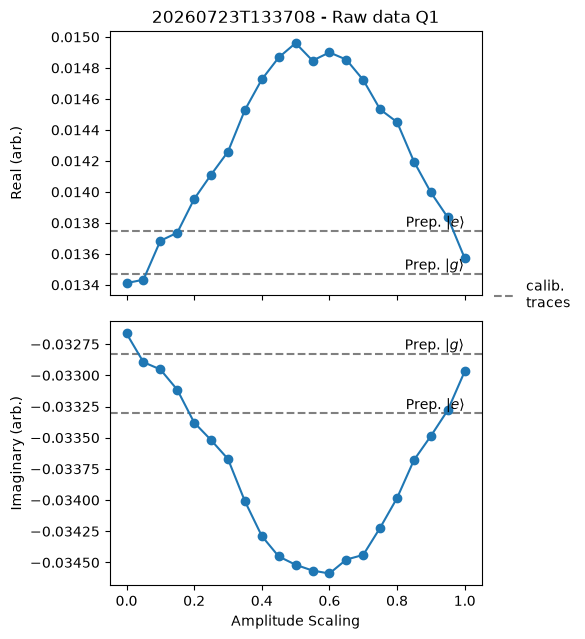

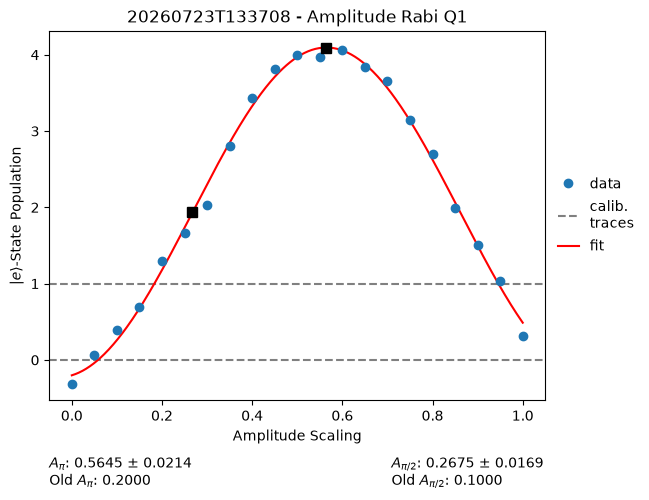

In [41]:
options = amplitude_rabi.experiment_workflow.options()

options.count(2**n_avg_exponent)
options.close_figures(False) # Plot figures

options.transition(transition)
options.cal_states(transition)

qubits_to_measure = [qubits[0]]

exp_workflow = amplitude_rabi.experiment_workflow(
    session=session,
    qpu=qpu,
    qubits=[q.uid for q in qubits_to_measure],
    amplitudes=[np.linspace(amp_min, amp_max, n_amp) for q in qubits_to_measure],
    options=options,
    temporary_parameters=temporary_parameters
)
workflow_result = exp_workflow.run()

#### Update Parameters

In [42]:
if update_global_parameters:
    qubit_to_measure.parameters = deepcopy(temporary_parameters[qubit_to_measure.uid])
    save(qpu, qpu_file_path)
    print('Updated global experiment parameters!\n')

analysis_workflow_result = workflow_result.tasks["analysis_workflow"]
qubit_parameters = analysis_workflow_result.output
pprint(qubit_parameters)
amplitude_rabi.update_qpu(qpu, qubit_parameters["new_parameter_values"])
if transition == 'ge':
    print("Drive amplitude pi ge: ", qubit_to_measure.parameters.ge_drive_amplitude_pi)
    print("Drive amplitude pi2 ge: ", qubit_to_measure.parameters.ge_drive_amplitude_pi2)
elif transition == 'ef':
    print("Drive amplitude pi ef: ", qubit_to_measure.parameters.ef_drive_amplitude_pi)
    print("Drive amplitude pi2 ef: ", qubit_to_measure.parameters.ef_drive_amplitude_pi2)

Updated global experiment parameters!

{'new_parameter_values': {'Q1': {'ge_drive_amplitude_pi': 0.5644895470505724+/-0.02140404252835977,
                                 'ge_drive_amplitude_pi2': 0.26748131952965976+/-0.016932272508152785}},
 'old_parameter_values': {'Q1': {'ge_drive_amplitude_pi': 0.2,
                                 'ge_drive_amplitude_pi2': 0.1}}}
Drive amplitude pi ge:  0.5644895470505724
Drive amplitude pi2 ge:  0.26748131952965976


## Ramsey

#### Experiment Parameters

In [67]:
update_global_parameters = True

detuning = 0.5e6
transition = set_transition('ge')

n_avg_exponent = 13

delay_min = 0
delay_max = 25e-6
n_delay = 201

temporary_parameters = {}
temp_pars = deepcopy(qubits[0].parameters)
temporary_parameters[q.uid] = temp_pars

#### Run Workflow

[2026.07.23 14:05:24.695] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.07.23 14:05:24.695] INFO      Workflow 'ramsey': execution started at 2026-07-23 11:05:24.679325Z           
[2026.07.23 14:05:24.697] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.07.23 14:05:24.934] INFO    Task 'temporary_qpu': started at 2026-07-23 11:05:24.934723Z
[2026.07.23 14:05:24.982] INFO    Task 'temporary_qpu': ended at 2026-07-23 11:05:24.982262Z
[2026.07.23 14:05:25.077] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-07-23 
[2026.07.23 14:05:25.077] INFO    11:05:25.077601Z
[2026.07.23 14:05:25.135] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-07-23 11:05:25.135664Z
[2026.07.23 14:05:25.224] INFO    Task 'create_experiment': started at 2026-07-23 11:05:25.224539Z
[2026.07.23 14:05:25.339] INFO    Task 'create_experiment': ended at 2026-07-23 11:05:25.339876Z
[202

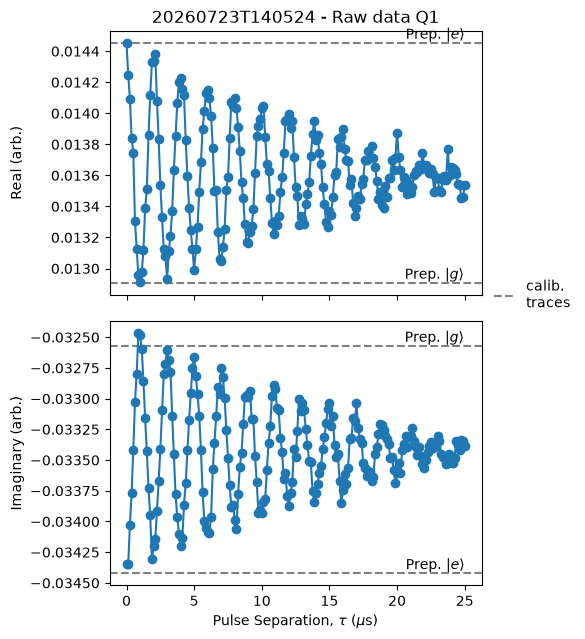

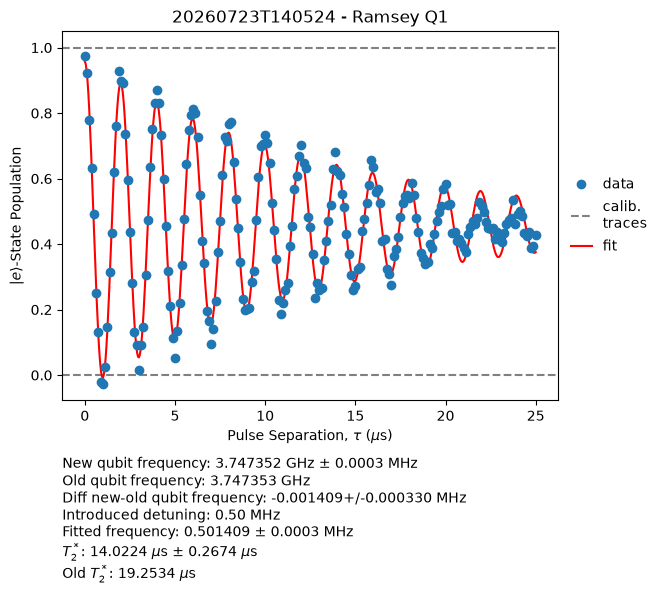

In [68]:
options = ramsey.experiment_workflow.options()
options.count(2**n_avg_exponent)
options.close_figures(False) # Plot figures

options.transition(transition)
options.cal_states(transition)

# Note: if neighbouring qubits are physically coupled by a resonator,
# you usually don't want to run Ramsey in parallel on them because
# your result will be skewed by strong residual-ZZ coupling.
# Next-nearest neighbours is typically okay.
# qubits_to_measure = [qubits[0], qubits[2]]
qubits_to_measure = [qubits[0]]

delays = [
    np.linspace(delay_min, delay_max, n_delay)
]
detunings = [
    detuning
]

exp_workflow = ramsey.experiment_workflow(
    session=session,
    qpu=qpu,
    qubits=[q.uid for q in qubits_to_measure],
    delays=delays,
    detunings=detunings,
    options=options,
    temporary_parameters=temporary_parameters
)

workflow_result = exp_workflow.run()

#### Update Parameters

In [69]:
if update_global_parameters:
    qubit_to_measure.parameters = deepcopy(temporary_parameters[qubit_to_measure.uid])
    save(qpu, qpu_file_path)
    print('Updated global experiment parameters!\n')

analysis_workflow_result = workflow_result.tasks["analysis_workflow"]
qubit_parameters = analysis_workflow_result.output
pprint(qubit_parameters)
ramsey.update_qpu(qpu, qubit_parameters["new_parameter_values"])
if transition == 'ge':
    print("ge_T2_star: ", qubit_to_measure.parameters.ge_T2_star)
    print("resonance_frequency_ge: ", qubit_to_measure.parameters.resonance_frequency_ge)
elif transition == 'ef':
    print("ef_T2_star: ", qubit_to_measure.parameters.ef_T2_star)
    print("resonance_frequency_ef: ", qubit_to_measure.parameters.resonance_frequency_ef)

Updated global experiment parameters!

{'new_parameter_values': {'Q1': {'ge_T2_star': 1.402241674419713e-05+/-2.674298304686989e-07,
                                 'resonance_frequency_ge': 3747351744.966767+/-330.06932055268004}},
 'old_parameter_values': {'Q1': {'ge_T2_star': 1.9253373465755175e-05,
                                 'resonance_frequency_ge': 3747353153.8766594}}}
ge_T2_star:  1.402241674419713e-05
resonance_frequency_ge:  3747351744.966767


## T1 Lifetime

#### Experiment Parameters

In [73]:
update_global_parameters = True

transition = set_transition('ge')

n_avg_exponent = 13

delay_min = 0
delay_max = 100e-6
n_delay = 51
log_spacing = True

temporary_parameters = {}
temp_pars = deepcopy(qubits[0].parameters)
temporary_parameters[q.uid] = temp_pars

#### Run Workflow

[2026.07.23 14:12:51.845] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.07.23 14:12:51.845] INFO      Workflow 'lifetime_measurement': execution started at 2026-07-23              
[2026.07.23 14:12:51.847] INFO      11:12:51.844392Z                                                              
[2026.07.23 14:12:51.847] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.07.23 14:12:52.182] INFO    Task 'temporary_qpu': started at 2026-07-23 11:12:52.182398Z
[2026.07.23 14:12:52.251] INFO    Task 'temporary_qpu': ended at 2026-07-23 11:12:52.251049Z
[2026.07.23 14:12:52.343] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-07-23 
[2026.07.23 14:12:52.343] INFO    11:12:52.340208Z
[2026.07.23 14:12:52.409] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-07-23 11:12:52.409554Z
[2026.07.23 14:12:52.561] INFO    Task 'create_experiment': started at 2026-07-23 11:

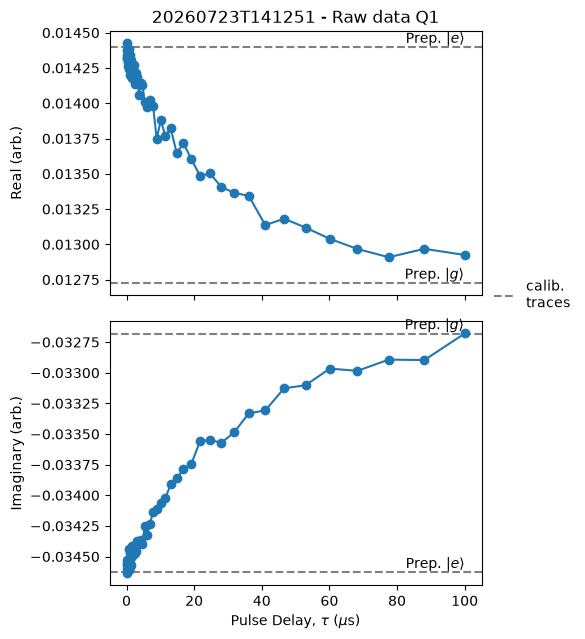

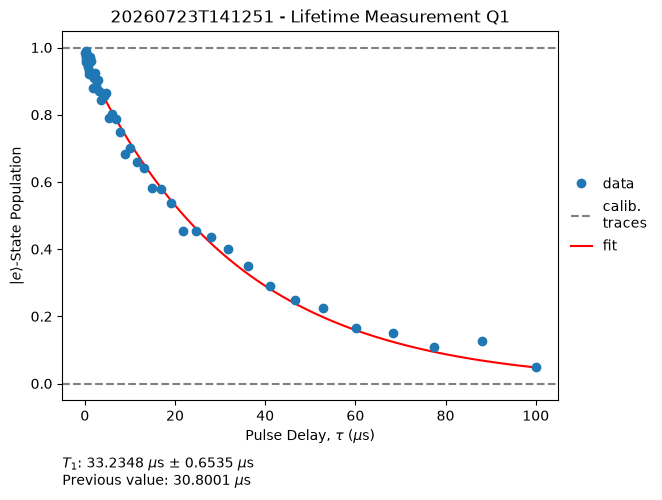

In [74]:
options = lifetime_measurement.experiment_workflow.options()
options.count(2**n_avg_exponent)
options.close_figures(False) # Plot figures


qubits_to_measure = [qubits[0]]

if log_spacing:
    delays = [log_sweep_help(delay_min, delay_max, n_delay)]
else:
    delays = [np.linspace(delay_min, delay_max, n_delay)]

exp_workflow = lifetime_measurement.experiment_workflow(
    session=session,
    qpu=qpu,
    qubits=[q.uid for q in qubits_to_measure],
    delays=delays,
    options=options,
    temporary_parameters=temporary_parameters 
)

workflow_result = exp_workflow.run()

#### Update Parameters

In [75]:
if update_global_parameters:
    qubit_to_measure.parameters = deepcopy(temporary_parameters[qubit_to_measure.uid])
    save(qpu, qpu_file_path)
    print('Updated global experiment parameters!\n')

analysis_workflow_result = workflow_result.tasks["analysis_workflow"]
qubit_parameters = analysis_workflow_result.output
pprint(qubit_parameters)
ramsey.update_qpu(qpu, qubit_parameters["new_parameter_values"])
if transition == 'ge':
    print("ge_T1: ", qubit_to_measure.parameters.ge_T1)
elif transition == 'ef':
    print("ef_T1: ", qubit_to_measure.parameters.ef_T1)

Updated global experiment parameters!

{'new_parameter_values': {'Q1': {'ge_T1': 3.323478050651062e-05+/-6.535138357748452e-07}},
 'old_parameter_values': {'Q1': {'ge_T1': 3.0800149698784506e-05}}}
ge_T1:  3.323478050651062e-05


## DRAG Calibration

#### Experiment Parameters

In [76]:
update_global_parameters = True

transition = set_transition('ge')

n_avg_exponent = 13

q_min = -0.05
q_max = 0.05
n_q = 31

temporary_parameters = {}
temp_pars = deepcopy(qubits[0].parameters)
temporary_parameters[q.uid] = temp_pars

#### Run Workflow

[2026.07.23 14:14:51.756] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.07.23 14:14:51.769] INFO      Workflow 'drag_q_scaling': execution started at 2026-07-23 11:14:51.756908Z   
[2026.07.23 14:14:51.770] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.07.23 14:14:51.995] INFO    Task 'temporary_qpu': started at 2026-07-23 11:14:51.995942Z
[2026.07.23 14:14:52.076] INFO    Task 'temporary_qpu': ended at 2026-07-23 11:14:52.075052Z
[2026.07.23 14:14:52.207] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-07-23 
[2026.07.23 14:14:52.217] INFO    11:14:52.207674Z
[2026.07.23 14:14:52.280] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-07-23 11:14:52.280843Z
[2026.07.23 14:14:52.392] INFO    Task 'create_experiment': started at 2026-07-23 11:14:52.390767Z
[2026.07.23 14:14:52.539] INFO    Task 'create_experiment': ended at 2026-07-23 11:14:52.539783Z
[202

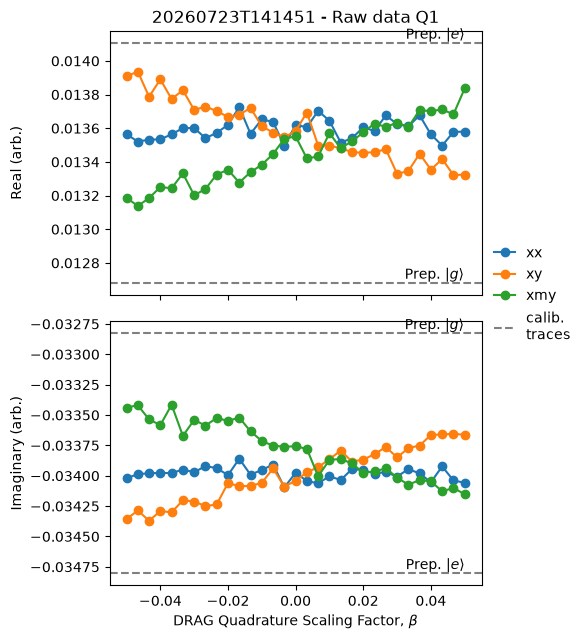

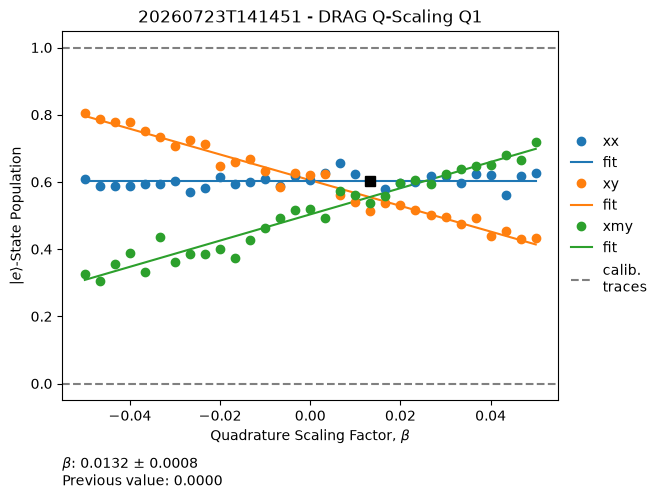

In [77]:
options = drag_q_scaling.experiment_workflow.options()
# options.update(True)  # updates the qubit parameter 'ge_drive_pulse["beta"]'
options.count(2**n_avg_exponent)
options.close_figures(False) # Plot figures

options.transition(transition)
options.cal_states(transition)

qubits_to_measure = [qubits[0]]

exp_workflow = drag_q_scaling.experiment_workflow(
    session=session,
    qpu=qpu,
    qubits=[q.uid for q in qubits_to_measure],
    q_scalings=[np.linspace(q_min, q_max, n_q) for _ in qubits_to_measure],
    options=options,
)
workflow_result = exp_workflow.run()

#### Update Parameters

In [78]:
if update_global_parameters:
    qubit_to_measure.parameters = deepcopy(temporary_parameters[qubit_to_measure.uid])
    print('Updated global experiment parameters!\n')

analysis_workflow_result = workflow_result.tasks["analysis_workflow"]
qubit_parameters = analysis_workflow_result.output
pprint(qubit_parameters)
ramsey.update_qpu(qpu, qubit_parameters["new_parameter_values"])
if transition == 'ge':
    print("ge_drive_pulse[beta]: ", qubit_to_measure.parameters.ge_drive_pulse["beta"])
elif transition == 'ef':
    print("ef_drive_pulse[beta]: ", qubit_to_measure.parameters.ef_drive_pulse["beta"])

Updated global experiment parameters!

{'new_parameter_values': {'Q1': {'ge_drive_pulse.beta': 0.013171235024880438+/-0.0008270917443031054}},
 'old_parameter_values': {'Q1': {'ge_drive_pulse.beta': 0}}}
ge_drive_pulse[beta]:  0.013171235024880438


## Hahn-Echo

#### Experiment Parameters

#### Run Workflow

#### Update Parameters